[*********************100%***********************]  10 of 10 completed


Column name changed to 'Close'


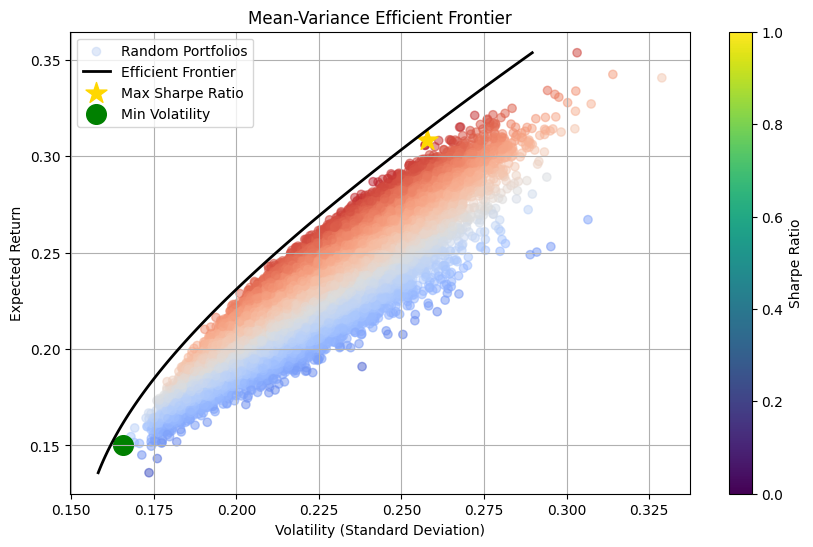

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from scipy.optimize import minimize

# Define stock tickers
tickers = ['AAPL', 'MSFT', 'GOOGL', 'AMZN', 'TSLA', 'JPM', 'JNJ', 'V', 'PG', 'NVDA']

# Download historical stock prices
data = yf.download(tickers, start="2015-01-01", end="2025-01-01")
# Access the adjusted closing price, handling potential column name changes
# If 'Adj Close' is not found, try 'Close', then try 'Adj. Close', and finally error if none exists
try:
    data = data['Adj Close']  # Original code
except KeyError:
    try:
        data = data['Close']  # Check for 'Close' column
        print("Column name changed to 'Close'")  # Indicate the change
    except KeyError:
        try:
            data = data['Adj. Close']  # Check for 'Adj. Close' column
            print("Column name changed to 'Adj. Close'")  # Indicate the change
        except KeyError:
            raise KeyError("Neither 'Adj Close', 'Close', nor 'Adj. Close' columns exist in the downloaded data.")

# Compute log returns
returns = np.log(data / data.shift(1)).dropna()

# Compute expected returns and covariance matrix
mean_returns = returns.mean() * 252  # Annualized mean returns
cov_matrix = returns.cov() * 252  # Annualized covariance matrix

# ... (rest of your code remains the same)
# Portfolio simulation
num_portfolios = 50000
results = np.zeros((3, num_portfolios))
weights_list = []

np.random.seed(42)
for i in range(num_portfolios):
    weights = np.random.random(len(tickers))
    weights /= np.sum(weights)  # Normalize weights

    port_return = np.dot(weights, mean_returns)
    port_volatility = np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights)))
    sharpe_ratio = port_return / port_volatility

    results[0, i] = port_return
    results[1, i] = port_volatility
    results[2, i] = sharpe_ratio
    weights_list.append(weights)

# Find the portfolio with the max Sharpe ratio
max_sharpe_idx = np.argmax(results[2])
max_sharpe_return = results[0, max_sharpe_idx]
max_sharpe_volatility = results[1, max_sharpe_idx]
max_sharpe_weights = weights_list[max_sharpe_idx]

# Find the minimum variance portfolio
min_vol_idx = np.argmin(results[1])
min_vol_return = results[0, min_vol_idx]
min_vol_volatility = results[1, min_vol_idx]
min_vol_weights = weights_list[min_vol_idx]

# Efficient frontier calculation
def portfolio_volatility(weights, mean_returns, cov_matrix):
    return np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights)))

def optimize_portfolio(target_return):
    constraints = ({'type': 'eq', 'fun': lambda w: np.sum(w) - 1},  # Weights sum to 1
                   {'type': 'eq', 'fun': lambda w: np.dot(w, mean_returns) - target_return})  # Target return constraint
    bounds = tuple((0, 1) for _ in range(len(tickers)))
    result = minimize(portfolio_volatility, x0=np.ones(len(tickers)) / len(tickers),
                      args=(mean_returns, cov_matrix), method='SLSQP', bounds=bounds, constraints=constraints)
    return result

target_returns = np.linspace(min(results[0]), max(results[0]), 100)
efficient_volatilities = []
for target in target_returns:
    res = optimize_portfolio(target)
    efficient_volatilities.append(res.fun)

# Plot the Mean-Variance Frontier
plt.figure(figsize=(10, 6))
plt.scatter(results[1, :], results[0, :], c=results[2, :], cmap='coolwarm', alpha=0.5, label='Random Portfolios')
plt.plot(efficient_volatilities, target_returns, 'k-', linewidth=2, label='Efficient Frontier')
plt.scatter(max_sharpe_volatility, max_sharpe_return, marker='*', color='gold', s=250, label='Max Sharpe Ratio')
plt.scatter(min_vol_volatility, min_vol_return, marker='o', color='green', s=200, label='Min Volatility')

plt.xlabel('Volatility (Standard Deviation)')
plt.ylabel('Expected Return')
plt.title('Mean-Variance Efficient Frontier')
plt.legend()
plt.colorbar(label='Sharpe Ratio')
plt.grid(True)
plt.show()
